# Lab 3 - Exploratory Data Analysis (EDA)
WASAN SAEED ALDOSSARY
2240007802

Dataset: Amazon E-Commerce Sales Dataset

This notebook applies EDA techniques including data cleaning,
visualization, and pattern analysis.

## 1. Loading the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI


## 2. Data Structure

In [2]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (10000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount     

,quantity,unit_price,discount,shipping_cost,total_sales
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.01440,25126.511133,0.149968,85.053192,64212.910555
std,1.42035,14343.922332,0.086828,37.575284,50992.635082
min,1.00000,214.200000,0.000000,20.010000,309.939600
25%,2.00000,12657.827500,0.070000,52.507500,24037.196775
50%,3.00000,24880.490000,0.150000,84.995000,50287.177500
75%,4.00000,37544.640000,0.220000,117.680000,93417.891825
max,5.00000,49981.880000,0.300000,149.950000,249155.530000


## 4. Missing Values

In [3]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna("Unknown", inplace=True)

order_id          0
order_date        0
ship_date         0
delivery_date     0
order_status      0
customer_id       0
customer_name     0
country           0
state             0
city              0
product_id        0
product_name      0
category          0
sub_category      0
brand             0
quantity          0
unit_price        0
discount          0
shipping_cost     0
total_sales       0
payment_method    0
dtype: int64


## 5. Duplicate Records

We check for duplicate rows and remove them to ensure data quality.

In [11]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


## 6. Univariate Analysis

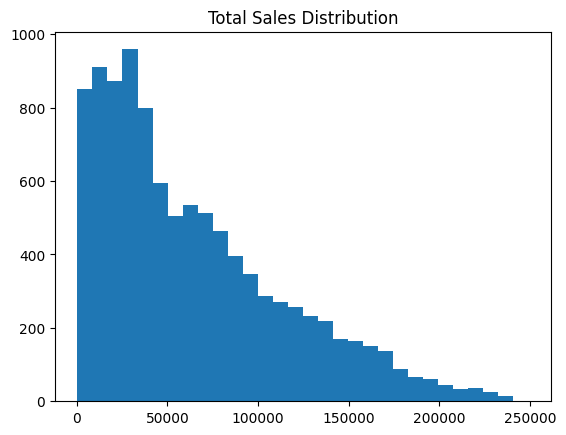

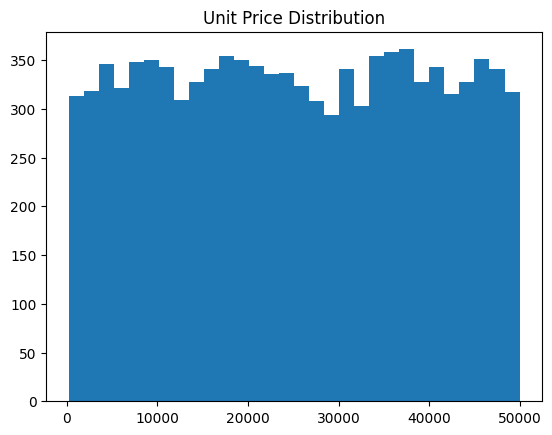

In [12]:
plt.hist(df["total_sales"], bins=30)
plt.title("Total Sales Distribution")
plt.show()

plt.hist(df["unit_price"], bins=30)
plt.title("Unit Price Distribution")
plt.show()

## 7. Bivariate Analysis

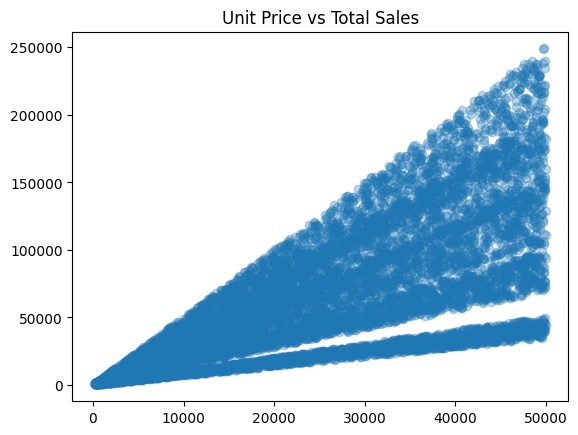

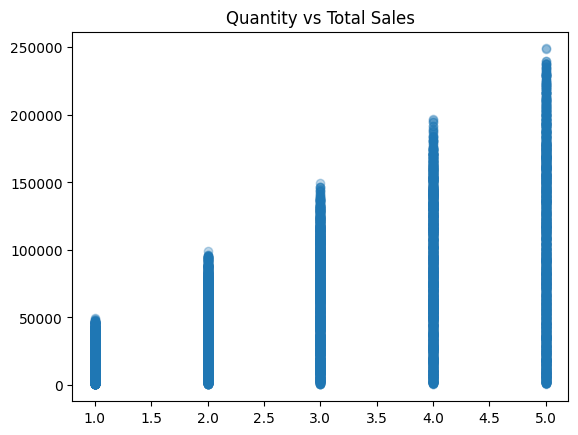

In [13]:
plt.scatter(df["unit_price"], df["total_sales"], alpha=0.3)
plt.title("Unit Price vs Total Sales")
plt.show()

plt.scatter(df["quantity"], df["total_sales"], alpha=0.3)
plt.title("Quantity vs Total Sales")
plt.show()

## 8. Correlation Analysis

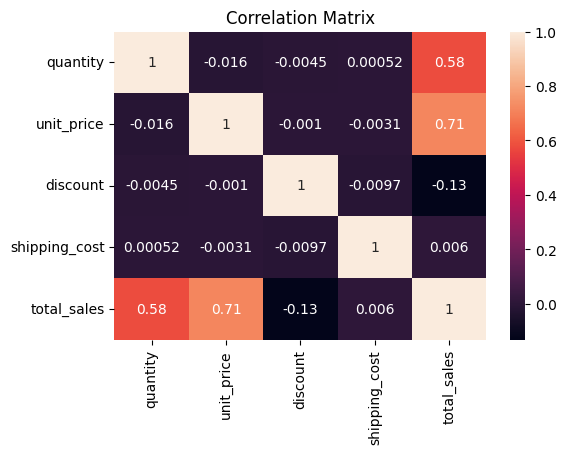

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[['quantity','unit_price','discount','shipping_cost','total_sales']].corr(),
    annot=True
)
plt.title("Correlation Matrix")
plt.show()

## 9. Time Analysis

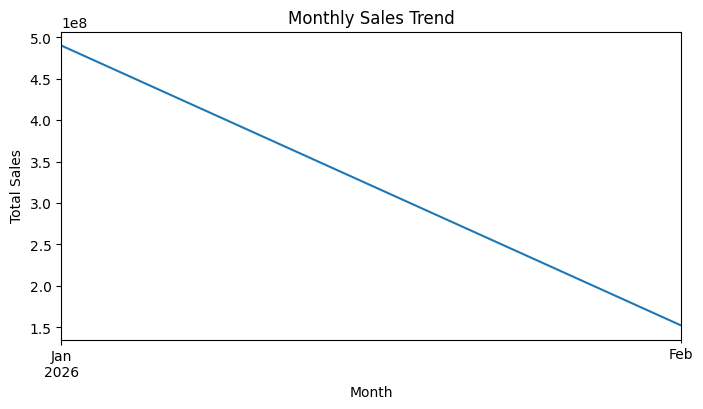

In [15]:
df["month"] = df["order_date"].dt.to_period("M")
monthly_sales = df.groupby("month")["total_sales"].sum()

monthly_sales.plot(figsize=(8,4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## 10. Insights and Findings

- The dataset contains 10,000 rows and 21 columns.
- No missing values were detected.
- No duplicate records were found.
- Total sales have a strong positive correlation with unit price.
- Quantity positively impacts total revenue.
- Discounts show a weak negative relationship with total sales.
- Sales performance varies across months.
- Shipping cost has minimal impact on revenue.

Unit price and quantity are the strongest drivers of sales.